<a href="https://colab.research.google.com/github/AnanyaAsthana/Machine-Learning/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


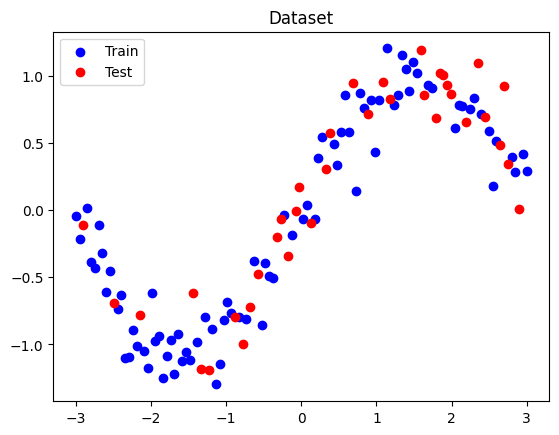

In [ ]:
np.random.seed(42)

# generate data
X = np.linspace(-3, 3, 120).reshape(-1,1)
y = np.sin(X) + np.random.normal(0, 0.2, size=X.shape)

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

plt.scatter(X_train, y_train, color='blue', label='Train')
plt.scatter(X_test, y_test, color='red', label='Test')
plt.legend()
plt.title("Dataset")
plt.show()


In [ ]:
degrees = range(1,16)
epsilons = [2**i for i in range(-18,51)]


In [ ]:
results = np.zeros((len(degrees), len(epsilons)))

for i, d in enumerate(degrees):
    for j, eps in enumerate(epsilons):

        model = make_pipeline(
            PolynomialFeatures(d),
            Ridge(alpha=eps)
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        results[i, j] = mse


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.13494e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.26988e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.53976e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.96313e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.92627e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

In [ ]:
best_idx = np.unravel_index(np.argmin(results), results.shape)
best_degree = degrees[best_idx[0]]
best_epsilon = epsilons[best_idx[1]]

print("Best degree:", best_degree)
print("Best epsilon:", best_epsilon)


Best degree: 4
Best epsilon: 3.814697265625e-06


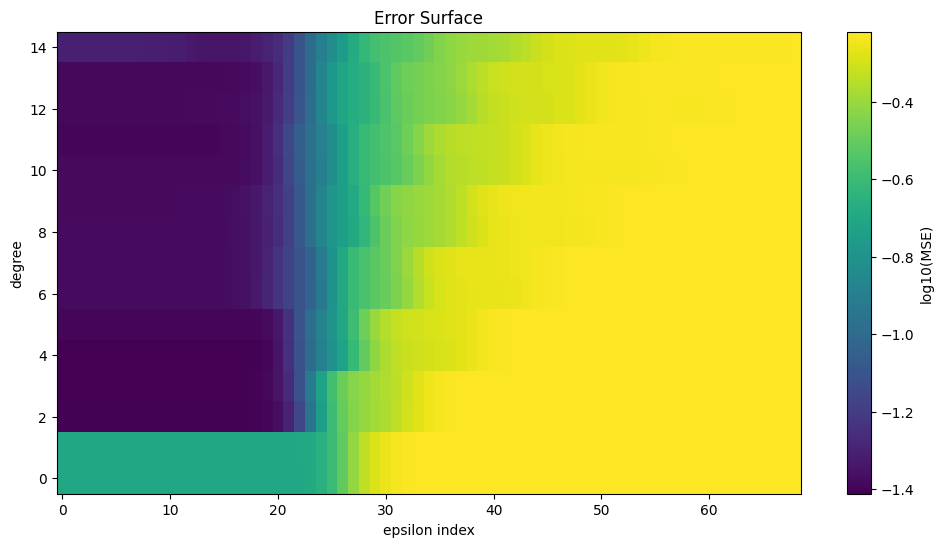

In [ ]:
plt.figure(figsize=(12,6))
plt.imshow(np.log10(results), aspect='auto', origin='lower')
plt.colorbar(label="log10(MSE)")
plt.xlabel("epsilon index")
plt.ylabel("degree")
plt.title("Error Surface")
plt.show()


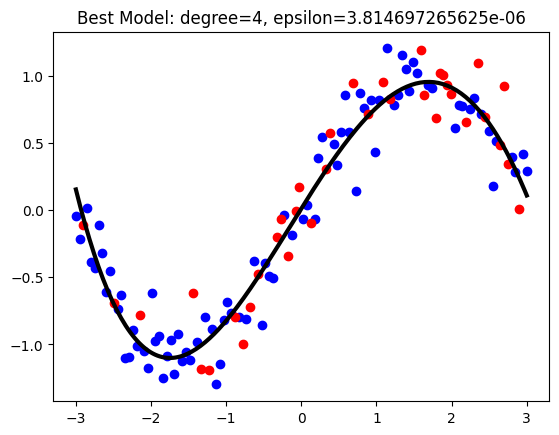

In [ ]:
best_model = make_pipeline(
    PolynomialFeatures(best_degree),
    Ridge(alpha=best_epsilon)
)

best_model.fit(X_train, y_train)

X_plot = np.linspace(-3,3,200).reshape(-1,1)
y_plot = best_model.predict(X_plot)

plt.scatter(X_train, y_train, color='blue')
plt.scatter(X_test, y_test, color='red')
plt.plot(X_plot, y_plot, color='black', linewidth=3)
plt.title(f"Best Model: degree={best_degree}, epsilon={best_epsilon}")
plt.show()
